In [2]:
# Import the required libraries. Add more as needed, e.g. for feature selection.
import pandas as pd
import numpy as np
import sklearn
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
from scipy.stats import mode
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2, VarianceThreshold
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import StratifiedKFold 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline 
from imblearn.pipeline import Pipeline  # for SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.tree import DecisionTreeClassifier
print("Done import")

Done import


In [3]:
# Read the train and test data from csv files to dataframes
train = pd.read_csv("train.txt")
test = pd.read_csv("test.txt")
# print(train.shape)
# print(train.head())

In [4]:
# Split the data set into features (the characteristics) and labels (the result - key)
# Preprocessing: Convert the current sparse format into a matrix so it can be processed by classifiers
def convert_sparse_to_matrix(filename):
    labels = []
    features = []
    
    with open(filename) as f:
        for line in f:
            values = list(map(int, line.split()))
            
            # First value is the label (0 or 1 / inactive or active drug)
            labels.append(values[0])
            
            # Rest are the active feature indices
            # Create a rows of zeros
            # So we could map one onto it representing the feature that's true later
            row = np.zeros(100001) # 100001 is because the dataset is 1 index so it need to fit
            
            # Turn on the active features
            if len(values) > 1:
                row[values[1:]] = 1
                
            features.append(row)
    
    return np.array(features), np.array(labels) # Convert into 2d array so it work with feature selector

X_train, y_train = convert_sparse_to_matrix("train.txt")
X_test, y_test = convert_sparse_to_matrix("test.txt")

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(800, 100001)
(800,)
(350, 100001)
(350,)


In [4]:
# # Feature selection steps - (Already Done in pipeline - this is just for reference):
# def feature_selector(train, test, y_train):
#     #2-step feature selection because there are too many features ()
#     # Remove useless features - Any feature that's very frequently being 0 should be removed
#     selector1 = VarianceThreshold(threshold=0.01)
#     selector1.fit(train) # Fit/train the selector to get familier with data
#     X_train_new = selector1.transform(train)
#     X_test_new = selector1.transform(test)
    
#     # Keep best K features
#     # k=500   
#     # k=1000  
#     # k=3000  
#     selector2 = SelectKBest(score_func = mutual_info_classif, k=3000) # k might change into like 3000 or something 
#     selector2.fit(X_train_new, y_train)
#     X_train_final = selector2.transform(X_train_new)
#     X_test_final = selector2.transform(X_test_new)
    
#     return X_train_final, X_test_final

# # Calling them on the train set
# X_train_final, X_test_final = feature_selector(X_train, X_test, y_train)

### Run some k range with default to have an idea of best K in SelectKBest for each classifier

In [7]:
k_values = [10, 50,100,150,200,300,500,700]

### KNN:
best_score_knn = 0
best_k_knn = None
accuracies_knn = []
errors_knn = []

print("KNN")
for k in k_values:
    print(f"Testing k={k}... ", end="", flush=True)

    # pipeline even though declared before cv they are applied after because of how it works => Feature select and SMOTE are applied correctly after k fold split
    pipeline = Pipeline(steps=[
        ('var', VarianceThreshold(threshold=0.01)),
        ('feat', SelectKBest(score_func=chi2, k=k)),
        ('smote', SMOTE(random_state=42)),
        ('model', KNeighborsClassifier())
    ])

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42) # Shuffle so that the score doesn't inflate due to ordering stuff

    # f-1 binary
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='f1', cv=cv, n_jobs=-1
    )

    avg = np.mean(cv_scores)
    std = np.std(cv_scores)

    print(f'F1: {avg:.3f} (std: {std:.3f})')

    accuracies_knn.append(avg)
    errors_knn.append(1 - avg)

    if avg > best_score_knn:
        best_score_knn = avg
        best_k_knn = k

print(f"Best k (features) for KNN: {best_k_knn}, F1: {best_score_knn:.3f}")

### Decision Tree
best_score_dt = 0
best_k_dt = None
accuracies_dt = []
errors_dt = []

print("Decision Tree")
for k in k_values:
    print(f"Testing k={k}... ", end="", flush=True)

    pipeline = Pipeline(steps=[
        ('var', VarianceThreshold(threshold=0.01)),
        ('feat', SelectKBest(score_func=chi2, k=k)),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(random_state=42))
    ])

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='f1', cv=cv, n_jobs=-1
    )

    avg = np.mean(cv_scores)
    std = np.std(cv_scores)

    print(f'F1: {avg:.3f} (std: {std:.3f})')

    accuracies_dt.append(avg)
    errors_dt.append(1 - avg)

    if avg > best_score_dt:
        best_score_dt = avg
        best_k_dt = k

print(f"Best k (features) for DT: {best_k_dt}, F1: {best_score_dt:.3f}")

### Naive Bayes:
best_score_nb = 0
best_k_nb = None
accuracies_nb = []
errors_nb = []

print("Naive Bayes")
for k in k_values:
    print(f"Testing k={k}... ", end="", flush=True)

    pipeline = Pipeline(steps=[
        ('var', VarianceThreshold(threshold=0.01)),
        ('feat', SelectKBest(score_func=chi2, k=k)),
        ('smote', SMOTE(random_state=42)),
        ('model', BernoulliNB())
    ])

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='f1', cv=cv, n_jobs=-1
    )

    avg = np.mean(cv_scores)
    std = np.std(cv_scores)

    print(f'F1: {avg:.3f} (std: {std:.3f})')

    accuracies_nb.append(avg)
    errors_nb.append(1 - avg)

    if avg > best_score_nb:
        best_score_nb = avg
        best_k_nb = k

print(f"Best k (features) for NB: {best_k_nb}, F1: {best_score_nb:.3f}")

KNN
Testing k=10... F1: 0.633 (std: 0.051)
Testing k=50... F1: 0.632 (std: 0.043)
Testing k=100... F1: 0.592 (std: 0.045)
Testing k=150... F1: 0.576 (std: 0.062)
Testing k=200... F1: 0.614 (std: 0.040)
Testing k=300... F1: 0.650 (std: 0.049)
Testing k=500... F1: 0.569 (std: 0.039)
Testing k=700... F1: 0.486 (std: 0.027)
Best k (features) for KNN: 300, F1: 0.650
Decision Tree
Testing k=10... F1: 0.499 (std: 0.087)
Testing k=50... F1: 0.544 (std: 0.040)
Testing k=100... F1: 0.561 (std: 0.059)
Testing k=150... F1: 0.514 (std: 0.053)
Testing k=200... F1: 0.597 (std: 0.046)
Testing k=300... F1: 0.514 (std: 0.078)
Testing k=500... F1: 0.564 (std: 0.081)
Testing k=700... F1: 0.554 (std: 0.051)
Best k (features) for DT: 200, F1: 0.597
Naive Bayes
Testing k=10... F1: 0.672 (std: 0.036)
Testing k=50... F1: 0.686 (std: 0.042)
Testing k=100... F1: 0.681 (std: 0.047)
Testing k=150... F1: 0.698 (std: 0.044)
Testing k=200... F1: 0.688 (std: 0.036)
Testing k=300... F1: 0.684 (std: 0.055)
Testing k=500

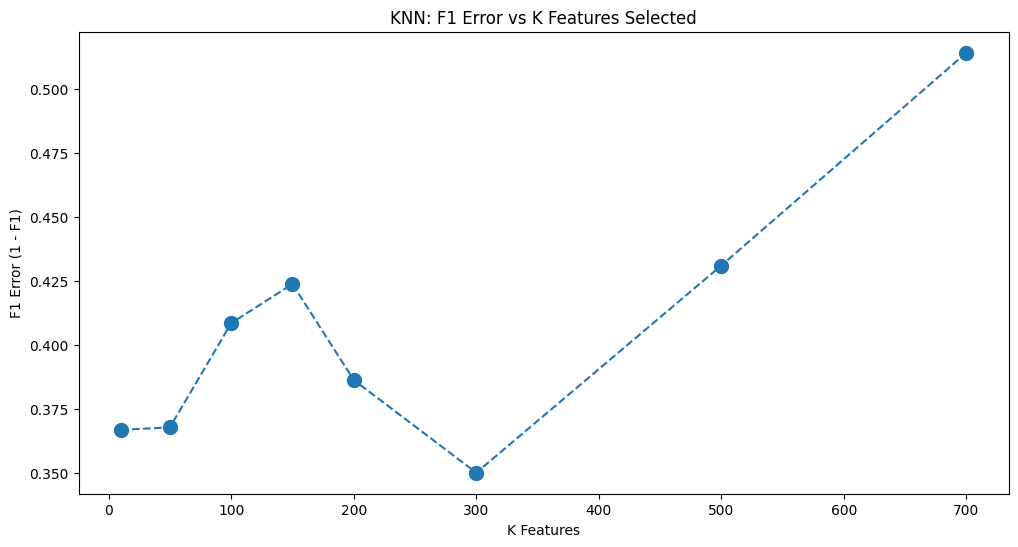

In [9]:
# KNN plot:
plt.figure(figsize=(12, 6))

plt.plot(k_values, errors_knn,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('KNN: F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error (1 - F1)')
plt.show()

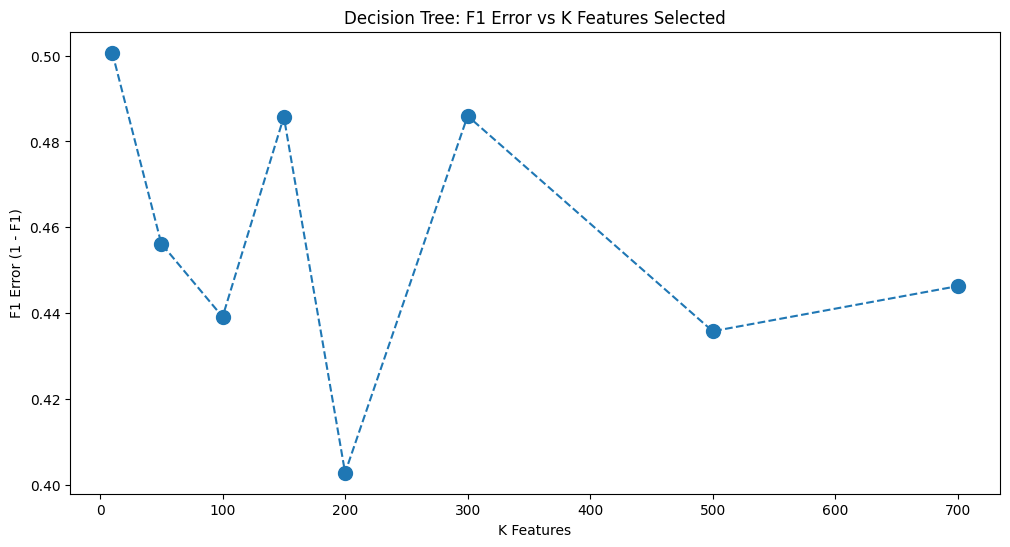

In [10]:
# Decision Tree plot
plt.figure(figsize=(12, 6))

plt.plot(k_values, errors_dt,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Decision Tree: F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error (1 - F1)')
plt.show()

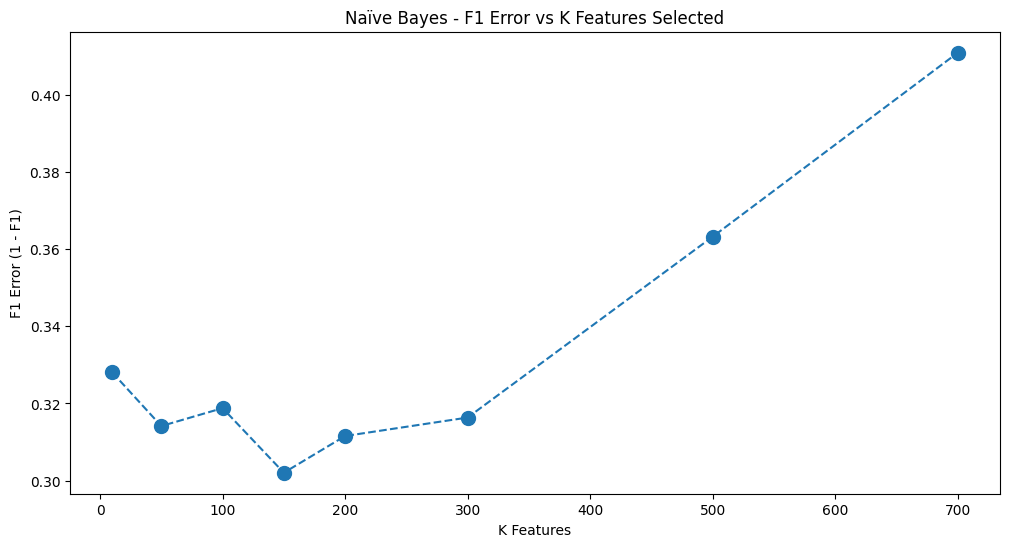

In [11]:
# Naive bayes plot
plt.figure(figsize=(12, 6))

plt.plot(k_values, errors_nb,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Naïve Bayes - F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error (1 - F1)')
plt.show()

## (1) KNN classifier

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import Normalizer

k_values = [250, 275, 300, 325, 350]
neighbor_values = [1, 3, 5, 9, 11, 15, 19, 23] # Too many neighbors = bad 
metric_values = ['euclidean', 'manhattan', 'cosine'] # only euclidean performs ok, others suck

best_score_knn = 0
best_k_features_knn = None
best_k_neighbors_knn = None
best_metric_knn = None

accuracies_knn = []

print("KNN")

for k_feat in k_values:
    for k_neigh in neighbor_values:
        for metric in metric_values:
            print(f"Testing features={k_feat}, neighbors={k_neigh}, metric={metric}... ", end="", flush=True)

            steps = [
                ('var', VarianceThreshold(threshold=0.01)),
                ('feat', SelectKBest(score_func=chi2, k=k_feat)), # chi2 because mutual info too way to long
                ('smote', SMOTE(random_state=42)),
            ]

            # Only normalize for cosine, but when it's not cosine, it doesn't normalize the data because other work well without it
            if metric == 'cosine':
                steps.append(('norm', Normalizer()))

            steps.append(('model', KNeighborsClassifier(
                n_neighbors=k_neigh,
                metric=metric
            )))

            pipeline = Pipeline(steps=steps)

            cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

            cv_scores = cross_val_score(
                pipeline, X_train, y_train,
                scoring='f1',
                cv=cv, n_jobs=-1
            )

            avg = np.mean(cv_scores)
            std = np.std(cv_scores)

            print(f'F1: {avg:.3f} (std: {std:.3f})')

            accuracies_knn.append((k_feat, k_neigh, metric, avg))

            if avg > best_score_knn:
                best_score_knn = avg
                best_k_features_knn = k_feat
                best_k_neighbors_knn = k_neigh
                best_metric_knn = metric

print("\nBest config:")
print(f"Features k = {best_k_features_knn}")
print(f"Neighbors = {best_k_neighbors_knn}")
print(f"Metric = {best_metric_knn}")
print(f"Best F1 = {best_score_knn:.3f}")

KNN
Testing features=250, neighbors=1, metric=euclidean... F1: 0.638 (std: 0.070)
Testing features=250, neighbors=1, metric=manhattan... F1: 0.523 (std: 0.034)
Testing features=250, neighbors=1, metric=cosine... F1: 0.217 (std: 0.026)
Testing features=250, neighbors=3, metric=euclidean... F1: 0.643 (std: 0.045)
Testing features=250, neighbors=3, metric=manhattan... F1: 0.568 (std: 0.033)
Testing features=250, neighbors=3, metric=cosine... F1: 0.223 (std: 0.025)
Testing features=250, neighbors=5, metric=euclidean... F1: 0.609 (std: 0.046)
Testing features=250, neighbors=5, metric=manhattan... F1: 0.609 (std: 0.062)
Testing features=250, neighbors=5, metric=cosine... F1: 0.220 (std: 0.027)
Testing features=250, neighbors=9, metric=euclidean... F1: 0.608 (std: 0.069)
Testing features=250, neighbors=9, metric=manhattan... F1: 0.597 (std: 0.077)
Testing features=250, neighbors=9, metric=cosine... F1: 0.218 (std: 0.017)
Testing features=250, neighbors=11, metric=euclidean... F1: 0.601 (std: 

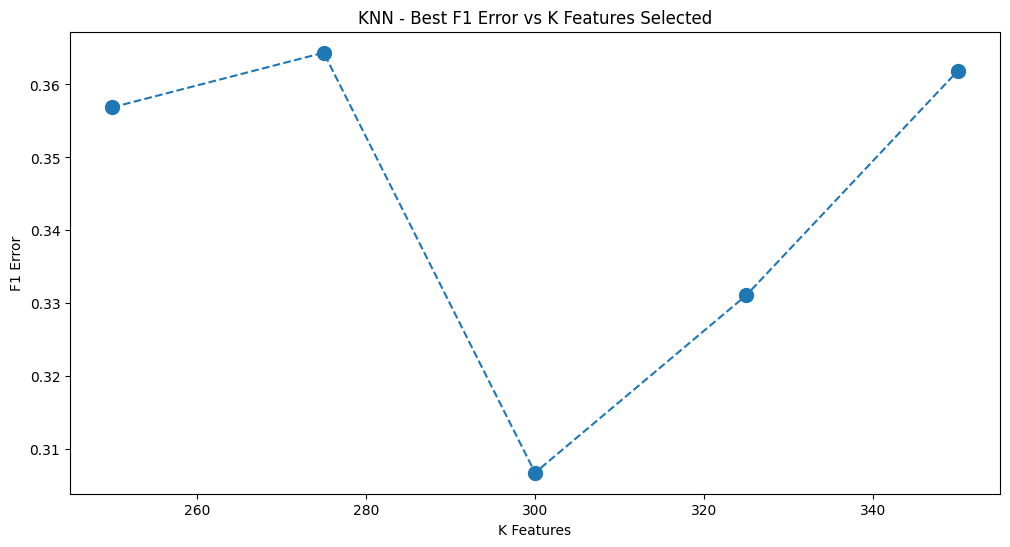

In [7]:
best_per_k_knn = []

for k in k_values:
    k_scores = [
        score for (kf, kn, m, score) in accuracies_knn
        if kf == k
    ]
    best_per_k_knn.append(1 - max(k_scores))

plt.figure(figsize=(12, 6))
plt.plot(k_values, best_per_k_knn,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('KNN - Best F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error')
plt.show()

## (2) Decision Tree

In [8]:
k_values = [100, 125, 150, 175, 190, 200, 210]
best_score_dt = 0
best_k_dt = None

accuracies_dt = []

print("Decision Tree") # Expecting this to be bad

for k_feat in k_values:
    print(f"Testing features={k_feat}... ", end="", flush=True)

    pipeline = Pipeline(steps=[
        ('var', VarianceThreshold(threshold=0.01)),
        ('feat', SelectKBest(score_func=chi2, k=k_feat)),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(random_state=42))
    ])

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42) # shuffle!!

    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='f1',
        cv=cv, n_jobs=-1
    )

    avg = np.mean(cv_scores)
    std = np.std(cv_scores)

    print(f'F1: {avg:.3f} (std: {std:.3f})')

    accuracies_dt.append(avg)

    if avg > best_score_dt:
        best_score_dt = avg
        best_k_dt = k_feat

print(f"\nBest config:")
print(f"Features k = {best_k_dt}")
print(f"Best F1 = {best_score_dt:.3f}")

Decision Tree
Testing features=100... F1: 0.561 (std: 0.059)
Testing features=125... F1: 0.583 (std: 0.031)
Testing features=150... F1: 0.514 (std: 0.053)
Testing features=175... F1: 0.558 (std: 0.061)
Testing features=190... F1: 0.551 (std: 0.030)
Testing features=200... F1: 0.597 (std: 0.046)
Testing features=210... F1: 0.513 (std: 0.076)

Best config:
Features k = 200
Best F1 = 0.597


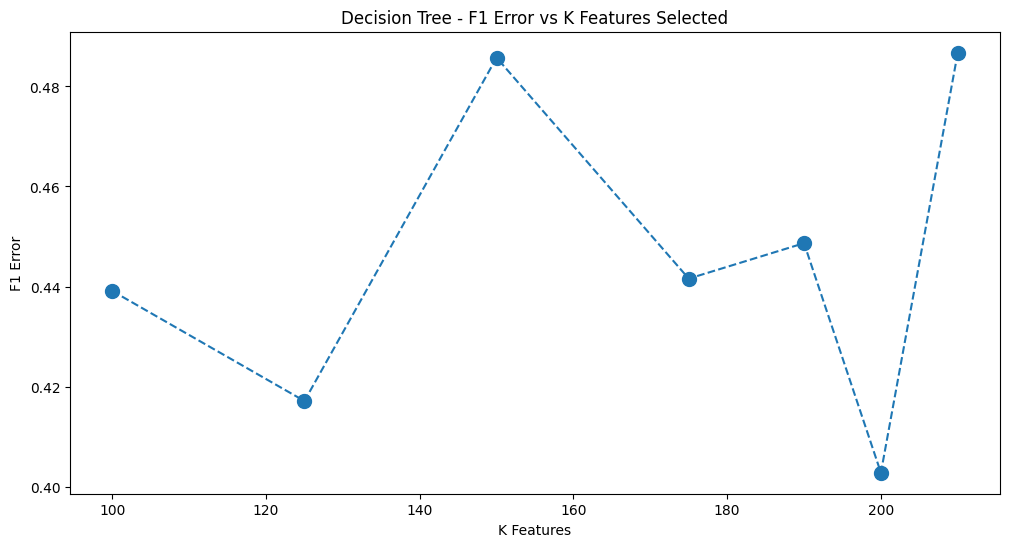

In [9]:
errors_dt = [1 - score for score in accuracies_dt]

plt.figure(figsize=(12, 6))

plt.plot(k_values, errors_dt,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Decision Tree - F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error')
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier

k_values =  [100, 125, 150,175 ,190, 200, 210]
depth_values = [1,2, 3, 4] # Probably low = better
criterion_values = ['gini', 'entropy', 'log_loss'] # log loss always = entropy?

best_score_dt = 0
best_k_dt = None
best_depth_dt = None
best_criterion_dt = None

accuracies_dt = []

print("Decision Tree")

for k_feat in k_values:
    for depth in depth_values:
        for crit in criterion_values:

            print(f"Testing k={k_feat}, depth={depth}, criterion={crit}... ", end="", flush=True)

            pipeline = Pipeline(steps=[
                ('var', VarianceThreshold(threshold=0.01)),
                ('feat', SelectKBest(score_func=chi2, k=k_feat)),
                ('smote', SMOTE(random_state=42)),
                ('model', DecisionTreeClassifier(
                    max_depth=depth,
                    criterion=crit,
                    random_state=42
                ))
            ])

            cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

            cv_scores = cross_val_score(
                pipeline, X_train, y_train,
                scoring='f1',
                cv=cv, n_jobs=-1
            )

            avg = np.mean(cv_scores)
            std = np.std(cv_scores)

            print(f'F1: {avg:.3f} (std: {std:.3f})')

            accuracies_dt.append((k_feat, depth, crit, avg))

            if avg > best_score_dt:
                best_score_dt = avg
                best_k_dt = k_feat
                best_depth_dt = depth
                best_criterion_dt = crit

print("\nBest config:")
print(f"Features k = {best_k_dt}")
print(f"Max depth = {best_depth_dt}")
print(f"Criterion = {best_criterion_dt}")
print(f"Best F1 = {best_score_dt:.3f}")

Decision Tree
Testing k=100, depth=1, criterion=gini... F1: 0.620 (std: 0.079)
Testing k=100, depth=1, criterion=entropy... F1: 0.620 (std: 0.079)
Testing k=100, depth=1, criterion=log_loss... F1: 0.620 (std: 0.079)
Testing k=100, depth=2, criterion=gini... F1: 0.643 (std: 0.041)
Testing k=100, depth=2, criterion=entropy... F1: 0.643 (std: 0.041)
Testing k=100, depth=2, criterion=log_loss... F1: 0.643 (std: 0.041)
Testing k=100, depth=3, criterion=gini... F1: 0.595 (std: 0.086)
Testing k=100, depth=3, criterion=entropy... F1: 0.590 (std: 0.086)
Testing k=100, depth=3, criterion=log_loss... F1: 0.590 (std: 0.086)
Testing k=100, depth=4, criterion=gini... F1: 0.554 (std: 0.037)
Testing k=100, depth=4, criterion=entropy... F1: 0.569 (std: 0.041)
Testing k=100, depth=4, criterion=log_loss... F1: 0.569 (std: 0.041)
Testing k=125, depth=1, criterion=gini... F1: 0.620 (std: 0.079)
Testing k=125, depth=1, criterion=entropy... F1: 0.620 (std: 0.079)
Testing k=125, depth=1, criterion=log_loss...

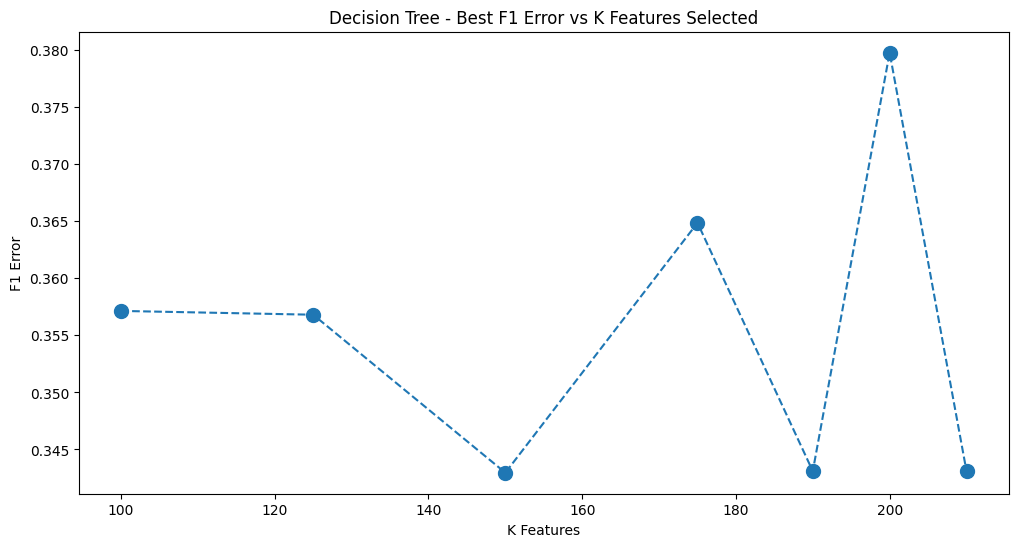

In [11]:
best_per_k_dt = []

for k in k_values:
    k_scores = [
        score for (kf, d, c, score) in accuracies_dt
        if kf == k
    ]
    best_per_k_dt.append(1 - max(k_scores))

plt.figure(figsize=(12, 6))
plt.plot(k_values, best_per_k_dt,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Decision Tree - Best F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error')
plt.show()

### (3) Naïve Bayes

In [15]:
k_values_nb = [30, 40, 50, 90, 100, 110, 120, 150, 200, 225, 250, 275, 300]
alpha_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

best_score_nb = 0
best_k_nb = None
best_alpha_nb = None

accuracies_nb = []

print("Naive Bayes")

for k_feat in k_values_nb:
    for alpha in alpha_values:

        print(f"Testing k={k_feat}, alpha={alpha}... ", end="", flush=True)

        pipeline = Pipeline(steps=[
            ('var', VarianceThreshold(threshold=0.01)),
            ('feat', SelectKBest(score_func=chi2, k=k_feat)),
            ('smote', SMOTE(random_state=42)),
            ('model', BernoulliNB(alpha=alpha))
        ])

        cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            scoring='f1',
            cv=cv,
            n_jobs=-1
        )

        avg = np.mean(cv_scores)
        std = np.std(cv_scores)

        print(f'F1: {avg:.3f} (std: {std:.3f})')

        accuracies_nb.append((k_feat, alpha, avg))

        if avg > best_score_nb:
            best_score_nb = avg
            best_k_nb = k_feat
            best_alpha_nb = alpha

print("\nBest config:")
print(f"Features k = {best_k_nb}")
print(f"Alpha = {best_alpha_nb}")
print(f"Best F1 = {best_score_nb:.3f}")

Naive Bayes
Testing k=30, alpha=0.001... F1: 0.685 (std: 0.051)
Testing k=30, alpha=0.01... F1: 0.685 (std: 0.051)
Testing k=30, alpha=0.1... F1: 0.685 (std: 0.051)
Testing k=30, alpha=0.5... F1: 0.676 (std: 0.040)
Testing k=30, alpha=1.0... F1: 0.676 (std: 0.040)
Testing k=30, alpha=2.0... F1: 0.667 (std: 0.032)
Testing k=30, alpha=5.0... F1: 0.667 (std: 0.032)
Testing k=40, alpha=0.001... F1: 0.695 (std: 0.051)
Testing k=40, alpha=0.01... F1: 0.686 (std: 0.042)
Testing k=40, alpha=0.1... F1: 0.686 (std: 0.042)
Testing k=40, alpha=0.5... F1: 0.686 (std: 0.042)
Testing k=40, alpha=1.0... F1: 0.686 (std: 0.042)
Testing k=40, alpha=2.0... F1: 0.686 (std: 0.042)
Testing k=40, alpha=5.0... F1: 0.666 (std: 0.046)
Testing k=50, alpha=0.001... F1: 0.694 (std: 0.046)
Testing k=50, alpha=0.01... F1: 0.694 (std: 0.046)
Testing k=50, alpha=0.1... F1: 0.694 (std: 0.046)
Testing k=50, alpha=0.5... F1: 0.694 (std: 0.046)
Testing k=50, alpha=1.0... F1: 0.686 (std: 0.042)
Testing k=50, alpha=2.0... F1

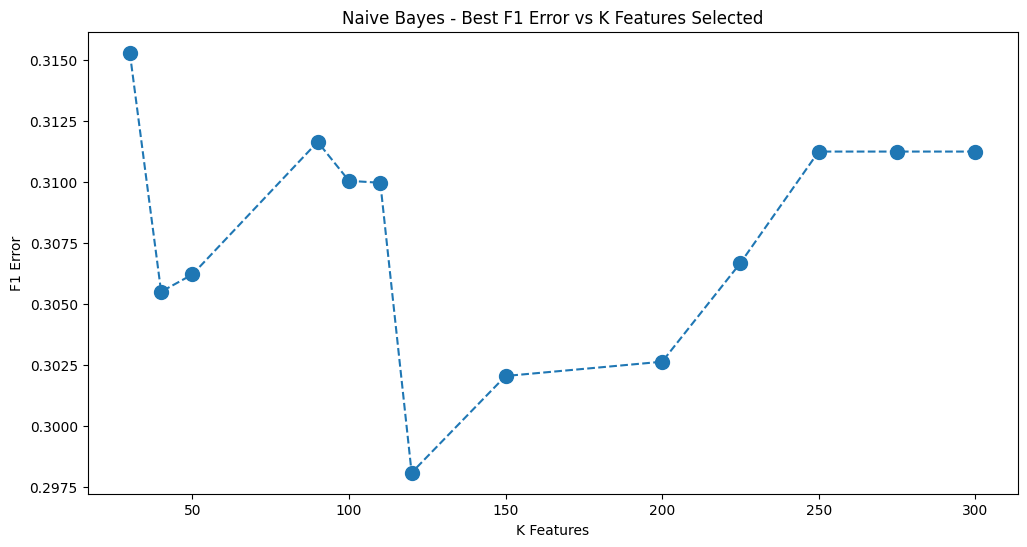

In [16]:
best_per_k_nb = []

for k in k_values_nb:
    k_scores = [
        score for (kf, a, score) in accuracies_nb
        if kf == k
    ]
    best_per_k_nb.append(1 - max(k_scores))

plt.figure(figsize=(12, 6))
plt.plot(k_values_nb, best_per_k_nb,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Naive Bayes - Best F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error')
plt.show()

In [13]:
k_values_nb = [45, 46, 47, 48, 49, 50, 51, 52, 53 ,54, 55, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 145, 146,147,148,149,150, 151, 152, 153, 154, 155]
alpha_values = [0.001, 0.01, 0.1, 0.5]

best_score_nb = 0
best_k_nb = None
best_alpha_nb = None

accuracies_nb = []

print("Naive Bayes")

for k_feat in k_values_nb:
    for alpha in alpha_values:

        print(f"Testing k={k_feat}, alpha={alpha}... ", end="", flush=True)

        pipeline = Pipeline(steps=[
            ('var', VarianceThreshold(threshold=0.01)),
            ('feat', SelectKBest(score_func=chi2, k=k_feat)),
            ('smote', SMOTE(random_state=42)),
            ('model', BernoulliNB(alpha=alpha))
        ])

        cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            scoring='f1',
            cv=cv,
            n_jobs=-1
        )

        avg = np.mean(cv_scores)
        std = np.std(cv_scores)

        print(f'F1: {avg:.3f} (std: {std:.3f})')

        accuracies_nb.append((k_feat, alpha, avg))

        if avg > best_score_nb:
            best_score_nb = avg
            best_k_nb = k_feat
            best_alpha_nb = alpha

print("\nBest config:")
print(f"Features k = {best_k_nb}")
print(f"Alpha = {best_alpha_nb}")
print(f"Best F1 = {best_score_nb:.3f}")

Naive Bayes
Testing k=45, alpha=0.001... F1: 0.689 (std: 0.050)
Testing k=45, alpha=0.01... F1: 0.681 (std: 0.040)
Testing k=45, alpha=0.1... F1: 0.681 (std: 0.040)
Testing k=45, alpha=0.5... F1: 0.676 (std: 0.040)
Testing k=46, alpha=0.001... F1: 0.686 (std: 0.042)
Testing k=46, alpha=0.01... F1: 0.686 (std: 0.042)
Testing k=46, alpha=0.1... F1: 0.686 (std: 0.042)
Testing k=46, alpha=0.5... F1: 0.676 (std: 0.040)
Testing k=47, alpha=0.001... F1: 0.686 (std: 0.042)
Testing k=47, alpha=0.01... F1: 0.686 (std: 0.042)
Testing k=47, alpha=0.1... F1: 0.686 (std: 0.042)
Testing k=47, alpha=0.5... F1: 0.676 (std: 0.040)
Testing k=48, alpha=0.001... F1: 0.684 (std: 0.047)
Testing k=48, alpha=0.01... F1: 0.684 (std: 0.047)
Testing k=48, alpha=0.1... F1: 0.684 (std: 0.047)
Testing k=48, alpha=0.5... F1: 0.684 (std: 0.047)
Testing k=49, alpha=0.001... F1: 0.684 (std: 0.047)
Testing k=49, alpha=0.01... F1: 0.684 (std: 0.047)
Testing k=49, alpha=0.1... F1: 0.684 (std: 0.047)
Testing k=49, alpha=0.5

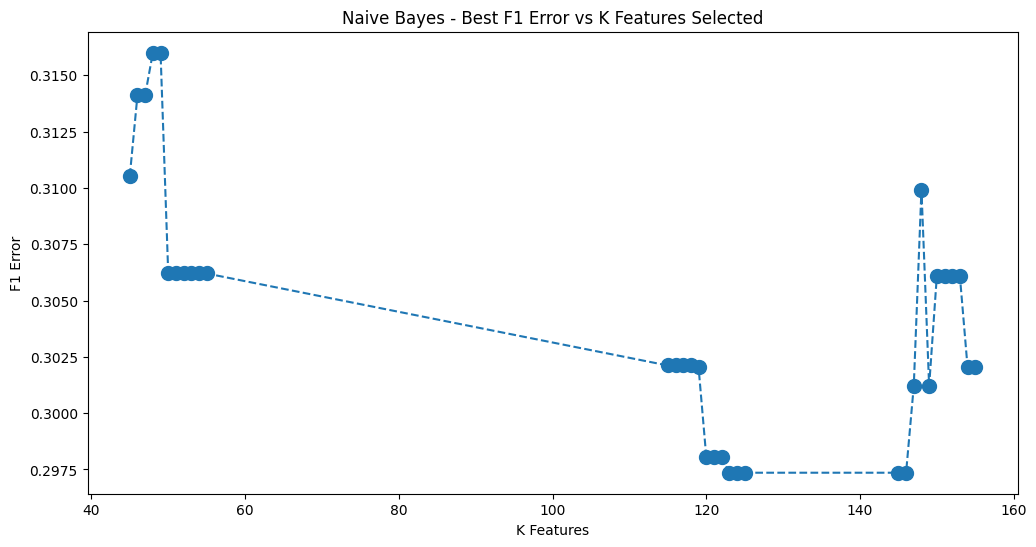

In [40]:
best_per_k_nb = []

for k in k_values_nb:
    k_scores = [
        score for (kf, a, score) in accuracies_nb
        if kf == k
    ]
    best_per_k_nb.append(1 - max(k_scores))

plt.figure(figsize=(12, 6))
plt.plot(k_values_nb, best_per_k_nb,
         linestyle='dashed',
         marker='o',
         markersize=10)

plt.title('Naive Bayes - Best F1 Error vs K Features Selected')
plt.xlabel('K Features')
plt.ylabel('F1 Error')
plt.show()

## (4) Neural Network (Dropped this one)

In [17]:
# # k_values_nn = list(range(22, 29))  # fine tune around 25
# # hidden_layer_sizes = [(75,), (100,), (125,), (150,)]
# # activations = ['tanh'] 
# # learning_rates = [0.01, 0.001]

# # k_values_nn = list(range(24, 32))  # [24,25,26,27,28,29,30,31]
# # hidden_layer_sizes = [(75,), (100,)]  # confirmed best two
# # learning_rates = [0.01, 0.001, 0.0005]  # try even smaller lr
# # activations = ['tanh']

# k_values_nn = [27, 28]
# hidden_layer_sizes = [(70,), (71,), (72,), (73,), (74,), (75,), (76,), (77,), (78,), (79,), (80,)]
# learning_rates = [0.001, 0.0008]
# activations = ['tanh']

# # k_values_nn = [28]  # confirmed sweet spot
# # hidden_layer_sizes = [(75,)]
# # learning_rates = [0.001, 0.0008]
# # activations = ['tanh']

# best_score_nn = 0
# best_k_nn = None
# best_hidden_nn = None
# best_lr_nn = None
# best_activation_nn = None
# errors_nn = []
# accuracies_nn = []

# for k in k_values_nn:
#     for hidden in hidden_layer_sizes:
#         for lr in learning_rates:
#             for activation in activations:
#                 print(f"Testing k={k}, hidden={hidden}, lr={lr}, activation={activation}... ", end="", flush=True)
#                 steps = []
#                 steps.append(('scaler', StandardScaler(with_mean=False)))
#                 steps.append(('var', VarianceThreshold(threshold=0.01)))
#                 steps.append(('feat', SelectKBest(score_func=f_classif, k=k)))
#                 steps.append(('smote', SMOTE(random_state=42)))
#                 steps.append(('model', MLPClassifier(
#                     hidden_layer_sizes=hidden,
#                     learning_rate_init=lr,
#                     activation=activation,
#                     max_iter=1000,
#                     random_state=42
#                 )))
#                 pipeline = Pipeline(steps=steps)

#                 cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
#                 cv_scores = cross_val_score(pipeline, X_train, y_train,
#                                             scoring='f1', cv=cv, n_jobs=-1)
#                 avg_cv_score = np.mean(cv_scores)
#                 print('F1: %.3f (std: %.3f)' % (avg_cv_score, np.std(cv_scores)))
#                 accuracies_nn.append(avg_cv_score)
#                 errors_nn.append(1 - avg_cv_score)

#                 if avg_cv_score > best_score_nn:
#                     best_score_nn = avg_cv_score
#                     best_k_nn = k
#                     best_hidden_nn = hidden
#                     best_lr_nn = lr
#                     best_activation_nn = activation

# print(f"Best k: {best_k_nn}, Best hidden: {best_hidden_nn}, Best lr: {best_lr_nn}, Best activation: {best_activation_nn}, Best F1: {best_score_nn:.3f}")

Testing k=27, hidden=(70,), lr=0.001, activation=tanh... F1: 0.655 (std: 0.045)
Testing k=27, hidden=(70,), lr=0.0008, activation=tanh... F1: 0.659 (std: 0.039)
Testing k=27, hidden=(71,), lr=0.001, activation=tanh... F1: 0.654 (std: 0.036)
Testing k=27, hidden=(71,), lr=0.0008, activation=tanh... F1: 0.650 (std: 0.031)
Testing k=27, hidden=(72,), lr=0.001, activation=tanh... F1: 0.654 (std: 0.036)
Testing k=27, hidden=(72,), lr=0.0008, activation=tanh... F1: 0.654 (std: 0.036)
Testing k=27, hidden=(73,), lr=0.001, activation=tanh... F1: 0.637 (std: 0.046)
Testing k=27, hidden=(73,), lr=0.0008, activation=tanh... F1: 0.637 (std: 0.046)
Testing k=27, hidden=(74,), lr=0.001, activation=tanh... F1: 0.644 (std: 0.025)
Testing k=27, hidden=(74,), lr=0.0008, activation=tanh... F1: 0.644 (std: 0.025)
Testing k=27, hidden=(75,), lr=0.001, activation=tanh... F1: 0.650 (std: 0.031)
Testing k=27, hidden=(75,), lr=0.0008, activation=tanh... F1: 0.650 (std: 0.031)
Testing k=27, hidden=(76,), lr=0.0

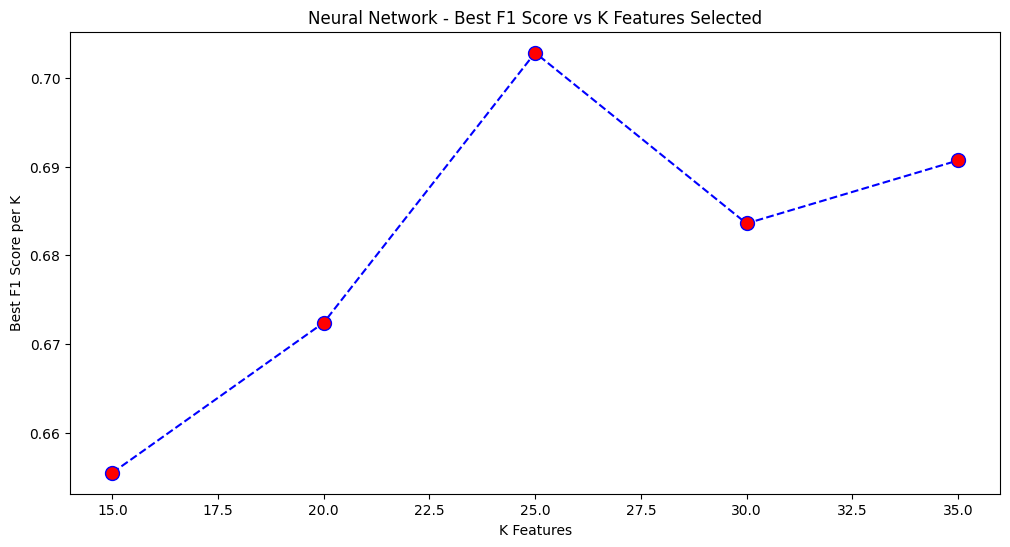

In [6]:
# # Best F1 per k for Neural Network
# best_per_k_nn = []
# for k in k_values_nn:
#     k_scores = [accuracies_nn[i] for i, (k_val, h_val, l_val, a_val) in
#                 enumerate([(k2, h2, l2, a2) 
#                            for k2 in k_values_nn 
#                            for h2 in hidden_layer_sizes 
#                            for l2 in learning_rates 
#                            for a2 in activations])
#                 if k_val == k]
#     best_per_k_nn.append(max(k_scores))

# plt.figure(figsize=(12, 6))
# plt.plot(k_values_nn, best_per_k_nn, color='blue', linestyle='dashed',
#          marker='o', markerfacecolor='red', markersize=10)
# plt.title('Neural Network - Best F1 Score vs K Features Selected')
# plt.xlabel('K Features')
# plt.ylabel('Best F1 Score per K')
# plt.show()

### Final prediction

In [5]:
# X_train, y_train = convert_sparse_to_matrix("train.txt")
# X_test, y_test = convert_sparse_to_matrix("test.txt")
final_steps_nb = []
final_steps_nb.append(('var', VarianceThreshold(threshold=0.01)))
final_steps_nb.append(('feat', SelectKBest(score_func=chi2, k=155)))
final_steps_nb.append(('smote', SMOTE(random_state=42)))
final_steps_nb.append(('model', BernoulliNB(alpha=0.5)))
final_pipeline_nb = Pipeline(steps=final_steps_nb)

# Fit on all training data
final_pipeline_nb.fit(X_train, y_train)

# Predict on test set
nb_predictions = final_pipeline_nb.predict(X_test)

# Save to file
np.savetxt('nb_predictions.txt', nb_predictions, fmt='%d')
print("Saved")

Saved


:=

=: